# Training

Training done in google colab, by loading on the drive the datasets (SPRITES, HMNIST), or by uploading it (Physionet).

In [ ]:
from google.colab import userdata
import os
# classic token on github - set up in secrets
token = userdata.get('GITHUB_TOKEN')
branch_name = 'gpvae-integration'
# Clone your private repo
os.system(f'git clone -b {branch_name} https://{token}@github.com/sebik2001/ImputeGAP-GP-VAE')

In [ ]:
%cd ImputeGAP-GP-VAE

In [ ]:
# load content of google drive (SPRITES file size is too large to be uploaded)
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

# dataset_folder = 'datasets/physionet'
# file_name = 'x_miss_nan.txt'
# text_file = True
# config_file = "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_physionet.yaml"

# dataset_folder = 'datasets/hmnist'
# dataset_folder = '/content/drive/MyDrive/gpvae/hmnist'
# file_name = 'x_miss_nan.npy'
# text_file = False
# config_file = "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_hmnist.yaml"

# dataset_folder = 'datasets/sprites'
dataset_folder = '/content/drive/MyDrive/gpvae/sprites'
file_name = 'x_miss_nan.npy'
text_file = False
config_file = "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_sprites.yaml"

if not os.path.exists(dataset_folder): os.makedirs(dataset_folder)
dataset_path = os.path.join(dataset_folder, file_name)

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae
import numpy as np

# initialize the time series object
ts = TimeSeries()

# load the dataset
if text_file:
  ts.load_series(dataset_path)
else:
  npy_file = np.load(dataset_path)
  ts.import_matrix(npy_file)

ts_m_imputed = gp_vae(ts.data,
                      config_file,
                      verbose=False)

In [ ]:
# Create a file zip of the folder containing training results
# From Colab is then possible to download the zip file
folder_name = "20260107_164259"
!zip -r model.zip "/content/ImputeGAP-GP-VAE/imputegap_assets/models/{folder_name}"

# Training results

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from utils import plot_training_results

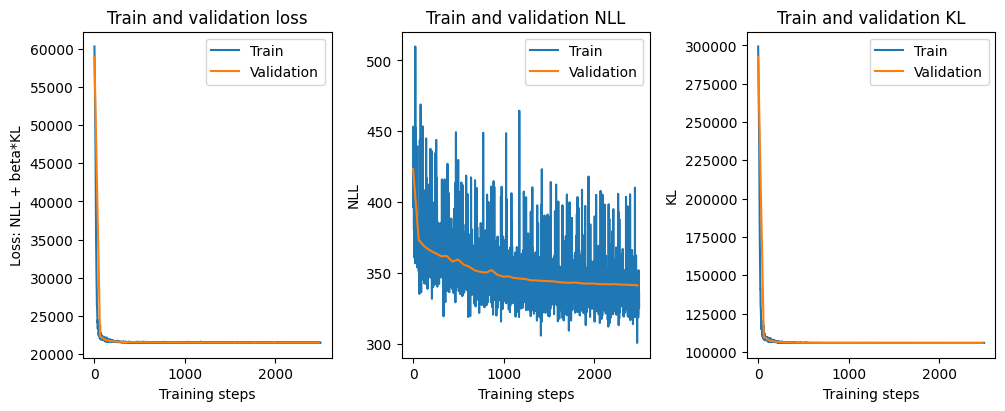

In [5]:
exp_folder = '/home/kaeslin/Downloads/physionet_trained'
plot_training_results(exp_folder)

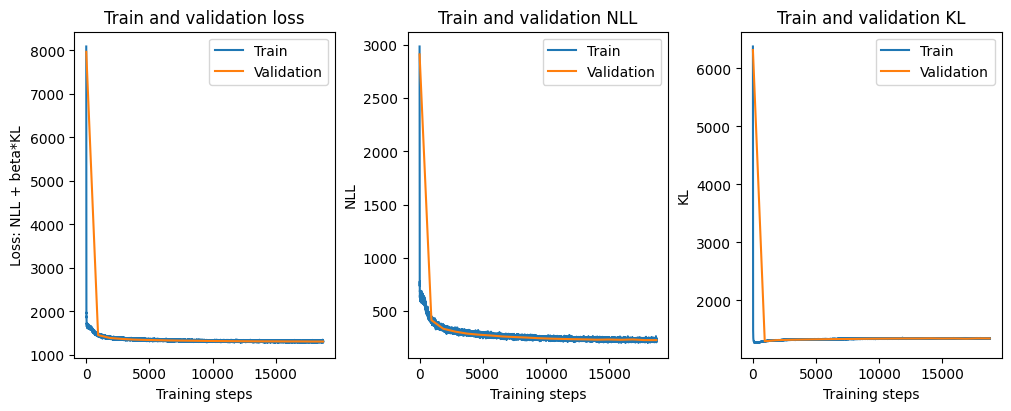

In [6]:
exp_folder = '/home/kaeslin/Downloads/hmnist_trained'
plot_training_results(exp_folder)

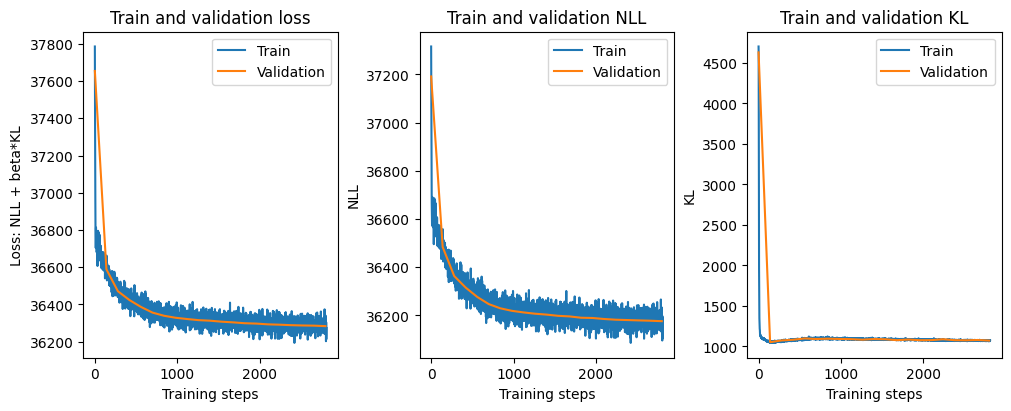

In [7]:
exp_folder = '/home/kaeslin/Downloads/sprites_trained'
plot_training_results(exp_folder)